# Teste de Modelos ARIMA


In [1]:
import itertools
import logging
import os
import time
import warnings
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from joblib import Parallel, delayed, parallel_config
from scipy import stats
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

sns.set_palette('colorblind')
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='mlflow')
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
EXPERIMENT_NAME = 'Brazil Tourism Forecasting ARIMA'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

### Transformações de Alvo (Target Transformations)

Três transformações de alvo são comparadas na grade de modelos. O modelo é sempre avaliado na **escala original**:
as previsões são convertidas de volta para contagens de chegadas antes do cálculo das métricas de validação.

| Opção | Transformação | Inversa |
|---|---|---|
| `none` | identidade (chegadas brutas) | identidade |
| `log` | `log(y)` | `exp(ŷ)` |
| `auto_stationary` | `AutoStationaryTransformer` (AutoML) | `inverse_transform` exato do pipeline ajustado |

**`auto_stationary`** provém do repositório complementar de:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2ª ed.
> (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), Licença MIT

Durante o `fit` (`src/transforms/target_transformations.py`), ele executa os testes explorados no notebook 3:

1. `check_trend` (Mann-Kendall). Se tendência detectada → `DetrendingTransformer` (linear).
2. `check_seasonality` em m = 12. Se sazonal → `DeseasonalizingTransformer` (médias de período).
3. `check_heteroscedastisticity` (White). Se heterocedástica → `AddMTransformer` quando necessário,
   seguido de `BoxCoxTransformer` com λ de Guerrero.

O transformador é ajustado separadamente em cada janela de treino.


In [2]:
import sys

# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
    BoxCoxTransformer,
)
from src.utils.ts_utils import forecast_bias, metrics_adapter  # noqa: E402

SEASONAL_PERIOD = 12
FREQ = 'ME'


def fit_auto_stationary(train_series):
    """Fit a fresh AutoStationaryTransformer (Mann-Kendall trend, Guerrero Box-Cox)."""
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    transformer = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return transformer.fit(train_series, freq=FREQ)


def describe_pipeline(transformer):
    steps = [
        type(tr).__name__.replace('Transformer', '') for tr in transformer._pipeline
    ]
    return ' → '.join(steps) if steps else '(none)'


class IdentityTarget:
    """No target transformation."""

    @staticmethod
    def transform(y):
        return y

    @staticmethod
    def inverse_transform(y):
        return y


class LogTarget:
    """Natural log of the arrival counts; inverse is exp."""

    @staticmethod
    def transform(y):
        return np.log(y)

    @staticmethod
    def inverse_transform(y):
        return np.exp(y)


def fit_target_transform(name, train_series):
    """Return a fitted transformer exposing `transform` / `inverse_transform`."""
    if name == 'none':
        return IdentityTarget()
    if name == 'log':
        return LogTarget()
    if name == 'auto_stationary':
        return fit_auto_stationary(train_series)
    raise ValueError(f'unknown target transform: {name}')

## Preparação dos Dados

Diversas seleções de dados de treino são avaliadas na busca em grade:

- **`last_{14,12,10,8,6,4}y_covid_exog`** — últimos N anos com um regressor COVID 0/1 (`is_covid`) para absorver a quebra estrutural
- **`last_{14,12,10,8,6,4}y_covid_recovery_exog`** — mesmas janelas com **dois** regressores: `is_covid` (abr 2020–dez 2021) **e** `is_covid_recovery` (jan 2022–jun 2022), o período de recuperação imediatamente após a pandemia
- **`post_covid`** — apenas dados pós-COVID (2022 em diante); sem variáveis exógenas necessárias, sinal mais limpo
- **`post_covid_recovery_exog`** — mesma janela pós-COVID com `is_covid_recovery` (jan 2022–jun 2022)

Cada seleção é cruzada com as três transformações de alvo (`none`, `log`, `auto_stationary`).

Os dados são **treino + validação** (`train_ptbr.parquet` e `val_ptbr.parquet`, notebook 2). O conjunto de teste nunca é lido aqui.


In [3]:
def load_monthly(file_name):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[['arrival_count']].resample('ME').sum()


train_monthly = load_monthly('train_ptbr.parquet')
val_monthly = load_monthly('val_ptbr.parquet')
TRAIN_END = train_monthly.index[-1]
HORIZON = len(val_monthly)
assert val_monthly.index[0] == TRAIN_END + pd.offsets.MonthEnd(1)

# train + validation: every validation origin is cut from this history (never the test)
full_monthly = pd.concat([train_monthly, val_monthly])
dates = full_monthly.index.to_series()
full_monthly['is_covid'] = dates.between(COVID_START, COVID_END).astype(float)
full_monthly['is_covid_recovery'] = dates.between(
    POST_COVID_START, COVID_RECOVERY_END
).astype(float)
train_monthly = full_monthly.loc[:TRAIN_END]
val_monthly = full_monthly.loc[TRAIN_END + pd.offsets.MonthEnd(1) :]

window_years = [14, 12, 10, 8, 6, 4]

print(
    f'Train + validation: {full_monthly.index[0]:%b %Y} → '
    f'{full_monthly.index[-1]:%b %Y} ({len(full_monthly)} obs)'
)
print(f'Train             : up to {TRAIN_END:%b %Y} ({len(train_monthly)} obs)')
print(
    f'Validation year   : {val_monthly.index[0]:%b %Y} → '
    f'{val_monthly.index[-1]:%b %Y} ({HORIZON} obs)'
)


Train + validation: Jan 1989 → Aug 2025 (440 obs)
Train             : up to Aug 2024 (428 obs)
Validation year   : Sep 2024 → Aug 2025 (12 obs)


## Origens de Validação (Holdout Repetido)

Um único ano de validação de 12 meses pode selecionar um modelo ajustado apenas às peculiaridades daquele ano,
especialmente em séries não-estacionárias (Joseph & Tackes, cap. 19). O modelo é, portanto, avaliado em
**múltiplas janelas de validação não-sobrepostas de 12 meses**, cada uma com sua própria origem (o último mês em que o modelo é treinado):

- **Horizonte.** Cada janela possui `HORIZON` = 12 meses, simulando o uso real do modelo.
- **Origens pós-COVID** (`N_POST_COVID_ORIGINS` = 2). O fim do treino (cuja janela de validação é `val_ptbr.parquet`) e um ano antes: sempre os **dois anos mais recentes** dos dados.
- **Origens pré-COVID** (`N_PRE_COVID_ORIGINS` = 2). Contadas regressivamente a partir do fim do treino, de ano em ano, as duas origens mais recentes cuja janela de validação termina **antes** de `COVID_START`.
- **Holdout, não validação cruzada.** As variáveis de COVID são exógenas, tornando o holdout por origem muito mais seguro do que K-fold aleatório ou bloqueado.


In [4]:
N_PRE_COVID_ORIGINS = 2
N_POST_COVID_ORIGINS = 2


def validation_window(origin):
    """First and last month forecast from `origin` (the last month the model sees)."""
    return origin + pd.offsets.MonthEnd(1), origin + pd.offsets.MonthEnd(HORIZON)


# candidate origins: the end of training, then one year back at a time
candidates = [TRAIN_END] + [
    TRAIN_END - pd.offsets.MonthEnd(12 * k) for k in range(1, len(train_monthly) // 12)
]
post_covid_origins = [o for o in candidates if validation_window(o)[0] > COVID_END][
    :N_POST_COVID_ORIGINS
]
pre_covid_origins = [o for o in candidates if validation_window(o)[1] < COVID_START][
    :N_PRE_COVID_ORIGINS
]
ORIGINS = sorted(pre_covid_origins + post_covid_origins)
LATEST_ORIGIN = TRAIN_END  # its validation window is val_ptbr.parquet
assert LATEST_ORIGIN in ORIGINS


def origin_label(origin):
    return f'{origin:%Y-%m}'


def val_actual_at(origin):
    start, end = validation_window(origin)
    return full_monthly.loc[start:end, 'arrival_count']


pd.DataFrame([
    {
        'origin': origin_label(origin),
        'phase': 'pre-COVID' if origin < COVID_START else 'post-COVID',
        'validation window': f'{start:%b %Y} → {end:%b %Y}',
        'history months': len(full_monthly.loc[:origin]),
        'validation arrivals': f'{val_actual_at(origin).sum():,.0f}',
    }
    for origin in ORIGINS
    for start, end in [validation_window(origin)]
])


,origin,phase,validation window,history months,validation arrivals
0,2017-08,pre-COVID,Sep 2017 → Aug 2018,344,"6,655,969"
1,2018-08,pre-COVID,Sep 2018 → Aug 2019,356,"6,408,872"
2,2023-08,post-COVID,Sep 2023 → Aug 2024,416,"6,340,127"
3,2024-08,post-COVID,Sep 2024 → Aug 2025,428,"8,849,640"


## Métricas de Avaliação e Linhas de Base

Cada modelo é avaliado em cada origem na escala original (contagens de chegadas), com as mesmas seis métricas do notebook 7:

| Métrica | Definição | Interpretação |
|---|---|---|
| **Seasonal MASE** | `MAE / MAE(seasonal naive, in-sample)` | **Métrica de seleção principal.** Abaixo de 1: melhor que o ingênuo sazonal no histórico |
| **RMSE** | `√mean((y − ŷ)²)` | Penaliza erros grandes |
| **MAE** | `mean(|y − ŷ|)` | Erro médio mensal absoluto em chegadas |
| **MAPE** | `mean(|y − ŷ| / y) × 100` | Erro percentual médio |
| **R²** | `1 − SSE / SST` | Proporção de variância explicada no ano de validação |
| **Forecast Bias** | `(Σy − Σŷ) / Σy × 100` | Positivo = subestimação das chegadas do ano |

**Ranking.** As configurações são ordenadas pelo **MASE sazonal médio entre as origens** (`mase_mean`).

**Linhas de Base (Baselines):**
- **naive**: repete o último mês de treino em todos os meses de validação.
- **seasonal naive**: repete o mesmo mês do ano anterior em cada mês de validação.


In [5]:
METRICS = ['rmse', 'mae', 'mape', 'r2', 'mase', 'forecast_bias']
AGG_METRICS = ['mase_mean', 'mase_worst', 'mase_post', 'n_origins']
METRIC_LABELS = {
    'mase_mean': f'MASE sazonal médio ({len(ORIGINS)} origens)',
    'mase_worst': 'MASE sazonal na pior origem',
    'rmse': 'RMSE (ano de validação)',
    'mae': 'MAE (ano de validação)',
    'mape': 'MAPE % (ano de validação)',
    'r2': 'R² (ano de validação)',
    'mase': 'MASE sazonal (ano de validação)',
    'forecast_bias': 'Viés de Previsão % (ano de validação)',
}
# seasonal differences distorted by the pandemic collapse and rebound
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))


def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    origin: seasonal_mase_scale(full_monthly.loc[:origin, 'arrival_count'])
    for origin in ORIGINS
}


def score(actual, forecast, origin):
    """Metrics of one origin on the original scale (arrival counts)."""
    forecast = pd.Series(np.asarray(forecast, dtype=float), index=actual.index)
    errors = actual - forecast
    mae = float(np.mean(np.abs(errors)))
    return {
        'rmse': float(np.sqrt(np.mean(errors**2))),
        'mae': mae,
        'mape': float(np.mean(np.abs(errors / actual)) * 100),
        'r2': float(r2_score(actual, forecast)),
        'mase': mae / MASE_SCALES[origin],
        'forecast_bias': float(metrics_adapter(forecast_bias, actual, forecast)),
    }


def aggregate(per_origin):
    """Combine the per-origin metrics of one configuration ({origin: metrics})."""
    mase = pd.Series({origin: m['mase'] for origin, m in per_origin.items()})
    post = mase[mase.index.isin(post_covid_origins)]
    latest = per_origin.get(LATEST_ORIGIN, {})
    return {
        'mase_mean': float(mase.mean()),
        'mase_worst': float(mase.max()),
        'mase_post': float(post.mean()) if len(post) else np.nan,
        'n_origins': len(mase),
        # the latest origin forecasts the validation year (val_ptbr.parquet)
        **{key: latest.get(key, np.nan) for key in METRICS},
    }


def baseline_forecasts(origin):
    history = full_monthly.loc[:origin, 'arrival_count']
    dates = val_actual_at(origin).index
    return {
        'naive': pd.Series(history.iloc[-1], index=dates),
        'seasonal_naive': pd.Series(
            history.reindex(dates - pd.offsets.MonthEnd(12)).to_numpy(), index=dates
        ),
    }


baseline_scores = {'naive': {}, 'seasonal_naive': {}}
for origin in ORIGINS:
    for name, forecast in baseline_forecasts(origin).items():
        baseline_scores[name][origin] = score(val_actual_at(origin), forecast, origin)

baselines = pd.DataFrame({
    name: aggregate(per_origin) for name, per_origin in baseline_scores.items()
}).T
BASELINE_MASE = float(baselines.loc['seasonal_naive', 'mase_mean'])
val_actual = val_monthly['arrival_count']

display(
    pd.DataFrame({
        name: {origin_label(o): m['mase'] for o, m in per_origin.items()}
        for name, per_origin in baseline_scores.items()
    }).rename_axis('MASE sazonal por origem')
)
baselines[[*AGG_METRICS, *METRICS]].astype(float).round(3)


,naive,seasonal_naive
MASE sazonal por origem,,
2017-08,3.325103,0.680184
2018-08,2.441616,0.977196
2023-08,3.393431,1.462635
2024-08,6.148383,4.023995


,mase_mean,mase_worst,mase_post,n_origins,rmse,mae,mape,r2,mase,forecast_bias
naive,3.827,6.148,4.771,4.0,460440.495,319530.000,33.968,-0.929,6.148,43.328
seasonal_naive,1.786,4.024,2.743,4.0,255353.116,209126.083,26.478,0.407,4.024,28.357


## Grade de Seleção de Modelos

Dimensões da grade:
- **Ordens SARIMAX**: `p, q ∈ {0,1,2}`, `d ∈ {0,1}`, `P, Q ∈ {0,1}`, `D ∈ {0,1}`, `s = 12` → 144 configurações.
- **Transformações de alvo**: `none`, `log`, `auto_stationary` → 3 opções.
- **Seleção de dados de treino**: 14 opções.
- **Total de configurações**: 6.048 combinações avaliadas em cada origem aplicável.


In [6]:
s = 12

p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
P_range = range(0, 2)
D_range = range(0, 2)
Q_range = range(0, 2)

sarimax_grid = list(
    itertools.product(p_range, d_range, q_range, P_range, D_range, Q_range)
)

TARGET_TRANSFORMS = ['none', 'log', 'auto_stationary']
EXOG_VARIANTS = {
    'covid_exog': ['is_covid'],
    'covid_recovery_exog': ['is_covid', 'is_covid_recovery'],
}


# ── training data selections of one origin (raw target + exogenous regressors) ──
def selection(frame, val, exog_columns):
    return {
        'raw_series': frame['arrival_count'],
        'exog_train': frame[exog_columns] if exog_columns else None,
        'exog_val': val[exog_columns] if exog_columns else None,
        'val_actual': val['arrival_count'],
    }


def data_selections_at(origin):
    """Selections that exist at `origin`; {'alias_of': key} marks a duplicate model."""
    history = full_monthly.loc[:origin]
    start, end = validation_window(origin)
    val = full_monthly.loc[start:end]
    has_covid = origin >= COVID_START
    selections = {}
    for years in window_years:
        window = history[history.index >= origin - pd.DateOffset(years=years)]
        base_key = f'last_{years}y_covid_exog'
        for suffix, exog_columns in EXOG_VARIANTS.items():
            key = f'last_{years}y_{suffix}'
            if has_covid:
                selections[key] = selection(window, val, exog_columns)
            elif key == base_key:
                # before the pandemic the flags are all zero: no regressor
                selections[key] = selection(window, val, None)
            else:
                selections[key] = {'alias_of': base_key}
    if origin > POST_COVID_START:
        post = history[history.index >= POST_COVID_START]
        selections['post_covid'] = selection(post, val, None)
        # Post-COVID window with recovery flag to model the Jan–Jun 2022 rebound
        selections['post_covid_recovery_exog'] = selection(
            post, val, ['is_covid_recovery']
        )
    return selections


selections_by_origin = {origin: data_selections_at(origin) for origin in ORIGINS}


# ── (origin × data selection × target transformation) configs ────────────────
def make_config(selection, transform_name):
    """Fit the target transformation on the training window and store the pieces."""
    transformer = fit_target_transform(transform_name, selection['raw_series'])
    is_auto = transform_name == 'auto_stationary'
    box_cox = (
        [tr for tr in transformer._pipeline if isinstance(tr, BoxCoxTransformer)]
        if is_auto
        else []
    )
    return {
        **selection,
        'target_transform': transform_name,
        'series': transformer.transform(selection['raw_series']),
        'transformer': transformer,
        'pipeline': describe_pipeline(transformer) if is_auto else transform_name,
        'boxcox_lambda': box_cox[0].boxcox_lambda if box_cox else None,
    }


model_configs = {
    (origin, data_key, transform_name): make_config(sel, transform_name)
    for origin, selections in selections_by_origin.items()
    for data_key, sel in selections.items()
    if 'alias_of' not in sel
    for transform_name in TARGET_TRANSFORMS
}
data_selections = selections_by_origin[LATEST_ORIGIN]  # every selection exists here
expected_origins = {
    key: sum(key in selections_by_origin[origin] for origin in ORIGINS)
    for key in data_selections
}

# ── what the AutoML pipeline chose for each training window (latest origin) ───
transform_summary = pd.DataFrame([
    {
        'data_selection': data_key,
        'n_train': len(cfg['raw_series']),
        'pipeline': cfg['pipeline'],
        'trend (MK p)': round(cfg['transformer']._trend_check['p_value'], 4),
        'seasonal': cfg['transformer']._seasonality_check['seasonal'],
        'hetero (White p)': round(cfg['transformer']._hetero_check['lm_p_value'], 4),
        'boxcox_λ': None
        if cfg['boxcox_lambda'] is None
        else round(cfg['boxcox_lambda'], 3),
    }
    for (origin, data_key, transform_name), cfg in model_configs.items()
    if transform_name == 'auto_stationary' and origin == LATEST_ORIGIN
]).set_index('data_selection')

n_configs = len(sarimax_grid) * len(data_selections) * len(TARGET_TRANSFORMS)
print(f'SARIMAX configs       : {len(sarimax_grid)}')
print(f'Target transformations: {len(TARGET_TRANSFORMS)}')
print(f'Data selections       : {len(data_selections)}')
print(f'Configurations        : {n_configs}')
print(f'Origins               : {", ".join(origin_label(o) for o in ORIGINS)}')
print(f'Fits (all origins)    : {len(sarimax_grid) * len(model_configs)}')
display(pd.Series(expected_origins, name='origins per data selection'))
transform_summary

SARIMAX configs       : 144
Target transformations: 3
Data selections       : 14
Configurations        : 6048
Origins               : 2017-08, 2018-08, 2023-08, 2024-08
Fits (all origins)    : 17280


last_14y_covid_exog             4
last_14y_covid_recovery_exog    4
last_12y_covid_exog             4
last_12y_covid_recovery_exog    4
last_10y_covid_exog             4
last_10y_covid_recovery_exog    4
last_8y_covid_exog              4
last_8y_covid_recovery_exog     4
last_6y_covid_exog              4
last_6y_covid_recovery_exog     4
last_4y_covid_exog              4
last_4y_covid_recovery_exog     4
post_covid                      2
post_covid_recovery_exog        2
Name: origins per data selection, dtype: int64

,n_train,pipeline,trend (MK p),seasonal,hetero (White p),boxcox_λ
data_selection,,,,,,
last_14y_covid_exog,169,Detrending → Deseasonalizing → AddM → BoxCox,0.0061,True,0.0048,1.649
last_14y_covid_recovery_exog,169,Detrending → Deseasonalizing → AddM → BoxCox,0.0061,True,0.0048,1.649
last_12y_covid_exog,145,Detrending → Deseasonalizing → AddM → BoxCox,0.0017,True,0.0397,2.000
last_12y_covid_recovery_exog,145,Detrending → Deseasonalizing → AddM → BoxCox,0.0017,True,0.0397,2.000
last_10y_covid_exog,121,Detrending → Deseasonalizing → AddM → BoxCox,0.0041,True,0.0015,2.000
last_10y_covid_recovery_exog,121,Detrending → Deseasonalizing → AddM → BoxCox,0.0041,True,0.0015,2.000
last_8y_covid_exog,97,Deseasonalizing → AddM → BoxCox,0.0741,True,0.0045,2.000
last_8y_covid_recovery_exog,97,Deseasonalizing → AddM → BoxCox,0.0741,True,0.0045,2.000
last_6y_covid_exog,73,Deseasonalizing → AddM → BoxCox,0.1658,True,0.0152,1.688


## Configuração do MLflow

`mlflow.statsmodels.autolog` está **desativado** por desempenho e estabilidade de paralelismo.
Cada execução registra explicitamente seus parâmetros e métricas. Apenas o melhor modelo é salvo como artefato.
O servidor de rastreamento é configurado via `MLFLOW_TRACKING_URI`.


In [7]:
mlflow.statsmodels.autolog(disable=True)

print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment  : {experiment.name} (id {experiment.experiment_id})')

Tracking URI: http://localhost:5000
Experiment  : Brazil Tourism Forecasting ARIMA (id 1)


In [8]:
# physical cores: SARIMAX fits are CPU-bound, hyper-threads add little
N_JOBS = max(1, (os.cpu_count() or 2) // 2)


def forecast_arrivals(fit, cfg):
    """Forecast the validation window on the transformed scale, back to arrivals."""
    index = cfg['val_actual'].index
    transformed = np.asarray(fit.forecast(steps=len(index), exog=cfg['exog_val']))
    forecast = cfg['transformer'].inverse_transform(pd.Series(transformed, index=index))
    return forecast.to_numpy()


def fit_one(origin, data_key, transform_name, cfg, order_spec):
    """Fit and score one grid point at one origin (worker process, no MLflow)."""
    p, d, q, P, D, Q = order_spec
    result = {
        'origin': origin,
        'data_selection': data_key,
        'target_transform': transform_name,
        'order': (p, d, q),
        'seasonal_order': (P, D, Q, s),
    }
    start = time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit = SARIMAX(
                cfg['series'],
                exog=cfg['exog_train'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)

            forecast = forecast_arrivals(fit, cfg)
        if not np.all(np.isfinite(forecast)):
            raise ValueError('non-finite forecast after inverse transform')
        result.update({
            'aicc': fit.aicc,
            'aic': fit.aic,
            'bic': fit.bic,
            **score(cfg['val_actual'], forecast, origin),
            'error': None,
        })
    except Exception as exc:
        result['error'] = str(exc)[:250]
    result['fit_seconds'] = time.perf_counter() - start
    return result


# ── phase 1: fit every (origin, grid point) in parallel ──────────────────────
tasks = [
    (origin, data_key, transform_name, cfg, order_spec)
    for (origin, data_key, transform_name), cfg in model_configs.items()
    for order_spec in sarimax_grid
]
print(f'Fitting {len(tasks)} models on {N_JOBS} workers...')

grid_start = time.perf_counter()
with parallel_config(backend='loky', inner_max_num_threads=1):
    results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(fit_one)(*task) for task in tasks
    )
print(f'Fitting done in {time.perf_counter() - grid_start:,.0f}s')

# before the pandemic both exogenous variants are the same model: copy its scores
fits = pd.DataFrame(results)
aliases = [
    fits[
        (fits['origin'] == origin) & (fits['data_selection'] == sel['alias_of'])
    ].assign(data_selection=key)
    for origin, selections in selections_by_origin.items()
    for key, sel in selections.items()
    if 'alias_of' in sel
]
fits = pd.concat([fits, *aliases], ignore_index=True)


# ── phase 2: one row per configuration, the per-origin scores aggregated ─────
def summarize_config(group):
    first = group.iloc[0]
    ok = group[group['error'].isna()]
    latest = ok[ok['origin'] == LATEST_ORIGIN]
    p, d, q = first['order']
    P, D, Q, _ = first['seasonal_order']
    errors = group['error'].dropna()
    row = {
        'data_selection': first['data_selection'],
        'target_transform': first['target_transform'],
        'order': first['order'],
        'seasonal_order': first['seasonal_order'],
        'd': d,
        'D': D,
        'run_name': (
            f'SARIMAX({p},{d},{q})({P},{D},{Q})[{s}] '
            f'({first["data_selection"]} | {first["target_transform"]})'
        ),
        'converged': len(ok) == expected_origins[first['data_selection']],
        'error': errors.iloc[0] if len(errors) else None,
        'fit_seconds': float(group['fit_seconds'].sum()),
        'origin_mase': dict(zip(ok['origin'], ok['mase'])),
        **{
            key: float(latest[key].iloc[0]) if len(latest) else np.nan
            for key in ['aicc', 'aic', 'bic']
        },
    }
    per_origin = {r['origin']: {k: r[k] for k in METRICS} for _, r in ok.iterrows()}
    row.update(aggregate(per_origin) if per_origin else {})
    return row


configs_df = pd.DataFrame([
    summarize_config(group)
    for _, group in fits.groupby(
        ['data_selection', 'target_transform', 'order', 'seasonal_order'], sort=False
    )
])


def log_result(client, result):
    cfg = model_configs[
        (LATEST_ORIGIN, result['data_selection'], result['target_transform'])
    ]
    p, d, q = result['order']
    P, D, Q, _ = result['seasonal_order']
    exog_label = (
        '+'.join(cfg['exog_train'].columns) if cfg['exog_train'] is not None else 'none'
    )
    params = {
        'p': p,
        'd': d,
        'q': q,
        'P': P,
        'D': D,
        'Q': Q,
        's': s,
        'transform': result['target_transform'],
        'ast_pipeline': cfg['pipeline'],
        'boxcox_lambda': cfg['boxcox_lambda'] or 'none',
        'data_selection': result['data_selection'],
        'exog': exog_label,
        'n_train': len(cfg['series']),
        'n_val': HORIZON,
        'eval_split': 'validation',
        'origins': ', '.join(origin_label(o) for o in sorted(result['origin_mase'])),
        'selection_metric': 'mean_seasonal_mase',
    }
    if result['error']:
        params['error'] = result['error']

    values = {
        **{key: result.get(key) for key in ['aicc', 'aic', 'bic', *METRICS]},
        **{key: result.get(key) for key in AGG_METRICS},
        **{
            f'mase_origin_{origin:%Y_%m}': value
            for origin, value in result['origin_mase'].items()
        },
        'fit_seconds': result['fit_seconds'],
    }
    timestamp = int(time.time() * 1000)
    metrics = [
        mlflow.entities.Metric(key, float(value), timestamp, 0)
        for key, value in values.items()
        if value is not None and np.isfinite(value)
    ]

    run = client.create_run(experiment.experiment_id, run_name=result['run_name'])
    client.log_batch(
        run.info.run_id,
        metrics=metrics,
        params=[mlflow.entities.Param(k, str(v)) for k, v in params.items()],
    )
    client.set_terminated(
        run.info.run_id, status='FINISHED' if result['converged'] else 'FAILED'
    )


# each run is 3 HTTP calls; threads overlap the request latency (~3x faster)
N_LOG_THREADS = 8
MLFLOW_MAX_MASE = 1.5  # only configurations below this mean seasonal MASE are logged

client = mlflow.MlflowClient()
log_start = time.perf_counter()
records = configs_df[
    configs_df['converged'] & (configs_df['mase_mean'] < MLFLOW_MAX_MASE)
].to_dict('records')
with ThreadPoolExecutor(max_workers=N_LOG_THREADS) as executor:
    list(
        tqdm(
            executor.map(lambda result: log_result(client, result), records),
            total=len(records),
            desc='Logging to MLflow',
        )
    )
print(
    f'Logged {len(records)} of {len(configs_df)} configurations '
    f'(mase_mean < {MLFLOW_MAX_MASE}) in {time.perf_counter() - log_start:,.0f}s'
)

results_df = (
    configs_df.query('converged').sort_values('mase_mean').reset_index(drop=True)
)
results_df['beats_seasonal_naive'] = results_df['mase_mean'] < BASELINE_MASE

print(f'Converged at every origin: {len(results_df)} / {len(configs_df)}')
print(
    f'{results_df["beats_seasonal_naive"].sum()} models beat the seasonal naive '
    f'(mean seasonal MASE {BASELINE_MASE:.3f})'
)
results_df[['run_name', *AGG_METRICS, 'rmse', 'mape', 'r2', 'forecast_bias']].head(
    10
).round(3)

Fitting 17280 models on 8 workers...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   25.4s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   27.3s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   31.4s
[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:   37.4s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   44.2s
[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed:   51.0s
[Parallel(n_jobs=8)]: Done 866 tasks      | elapsed:  1.0min
[Parallel(n_jobs=8)]: Done 1136 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done 1532 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done 2216 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done 2972 tasks      | elapsed:  2.0min
[Parallel(n_jobs=8)]: Done 3416 tasks      | elapsed:  2.6min
[Parallel(n_jobs=8)]: Done 3866 tasks      | elapsed:  3.1min
[Parallel(n_jobs=8)]: Done 4352 tasks      | elapsed:  3.6min
[Parallel(n_jobs=8)]: Done 4874 tasks      | elapsed:  4.0min
[P

Fitting done in 1,146s


Logging to MLflow: 100%|██████████| 299/299 [03:53<00:00,  1.28it/s]

Logged 299 of 6048 configurations (mase_mean < 1.5) in 233s
Converged at every origin: 5964 / 6048
1056 models beat the seasonal naive (mean seasonal MASE 1.786)


,run_name,mase_mean,mase_worst,mase_post,n_origins,rmse,mape,r2,forecast_bias
0,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992,1.258,1.137,4,103693.084,7.302,0.902,7.931
1,"SARIMAX(2,1,2)(0,1,1)[12] (last_4y_covid_recov...",1.072,1.450,1.276,4,113038.836,8.490,0.884,7.431
2,"SARIMAX(1,1,1)(0,1,1)[12] (last_4y_covid_recov...",1.137,1.465,1.452,4,113123.407,8.542,0.884,9.258
3,"SARIMAX(1,1,2)(0,1,1)[12] (last_4y_covid_recov...",1.167,1.559,1.479,4,110813.695,8.109,0.888,6.418
4,"SARIMAX(0,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.175,2.183,1.530,4,153634.495,14.138,0.785,5.330
5,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_exog ...",1.190,1.594,1.533,4,121969.346,9.530,0.865,10.597
6,"SARIMAX(1,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.199,2.190,1.535,4,154985.786,14.134,0.781,5.629
7,"SARIMAX(0,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.219,2.377,1.627,4,201791.935,13.711,0.630,10.541
8,"SARIMAX(0,1,2)(1,1,1)[12] (last_4y_covid_recov...",1.229,2.220,1.564,4,156537.101,14.369,0.777,5.283
9,"SARIMAX(1,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.237,2.344,1.612,4,200435.717,13.421,0.634,10.632


## Resultados


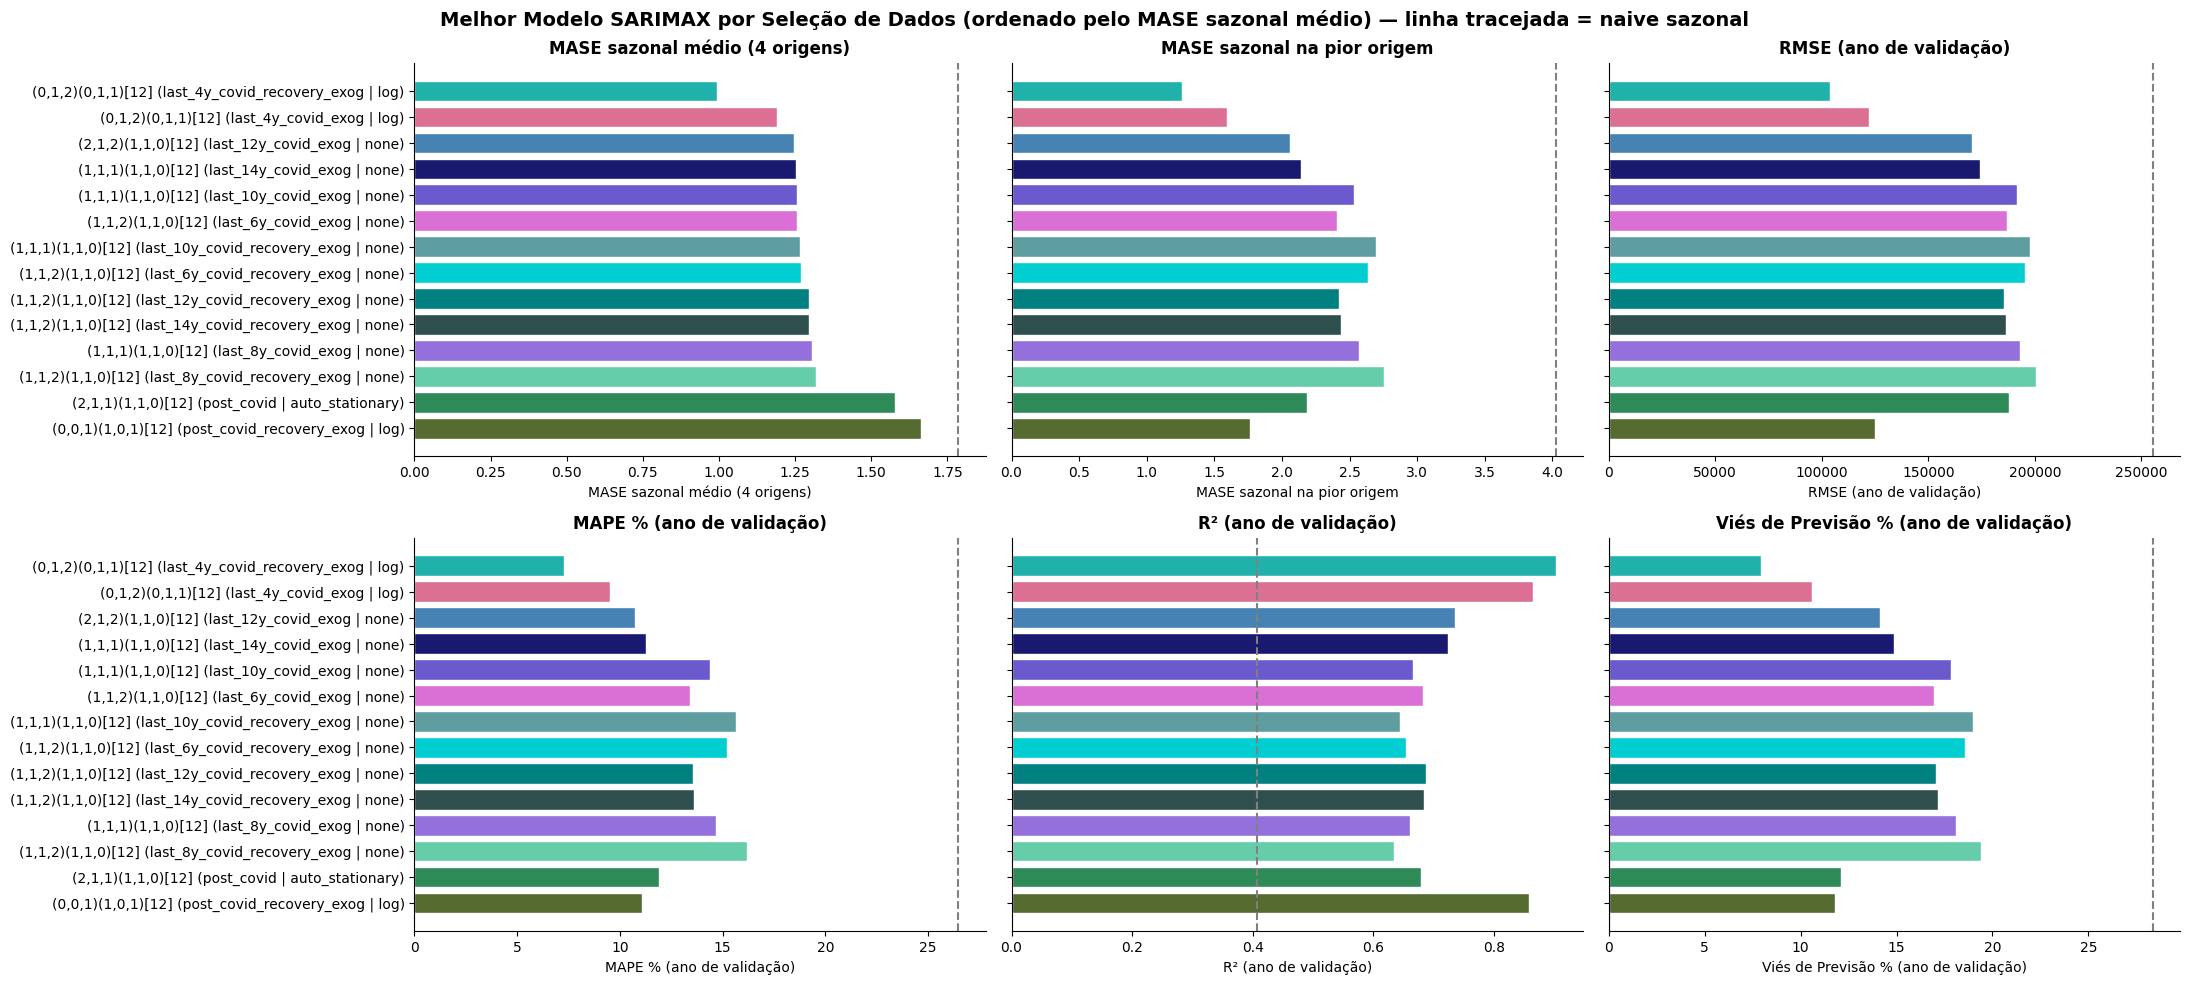

,data_selection,target_transform,run_name,mase_mean,mase_worst,mase_post,n_origins,rmse,mae,mape,r2,mase,forecast_bias,beats_seasonal_naive
0,last_4y_covid_recovery_exog,log,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992006,1.257627,1.137286,4,103693.084207,65358.584198,7.301984,0.902169,1.257627,7.930565,True
1,last_4y_covid_exog,log,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_exog ...",1.189968,1.594258,1.533209,4,121969.345691,82853.229982,9.530421,0.864643,1.594258,10.597316,True
2,last_12y_covid_exog,none,"SARIMAX(2,1,2)(1,1,0)[12] (last_12y_covid_exog...",1.247833,2.060725,1.739932,4,170632.872043,107095.413718,10.719793,0.735087,2.060725,14.143925,True
3,last_14y_covid_exog,none,"SARIMAX(1,1,1)(1,1,0)[12] (last_14y_covid_exog...",1.252051,2.139328,1.779857,4,174189.195541,111180.381215,11.286920,0.723929,2.139328,14.851485,True
4,last_10y_covid_exog,none,"SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_exog...",1.255705,2.534676,1.787020,4,191639.796073,131726.528198,14.392281,0.665844,2.534676,17.861951,True
5,last_6y_covid_exog,none,"SARIMAX(1,1,2)(1,1,0)[12] (last_6y_covid_exog ...",1.257337,2.409720,1.768629,4,186879.564044,125232.606125,13.408118,0.682238,2.409720,16.946538,True
6,last_10y_covid_recovery_exog,none,"SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_reco...",1.266176,2.693785,1.807963,4,197920.375097,139995.371180,15.664567,0.643582,2.693785,18.983195,True
7,last_6y_covid_recovery_exog,none,"SARIMAX(1,1,2)(1,1,0)[12] (last_6y_covid_recov...",1.269365,2.634152,1.792684,4,195173.116505,136896.241391,15.221453,0.653408,2.634152,18.562957,True
8,last_12y_covid_recovery_exog,none,"SARIMAX(1,1,2)(1,1,0)[12] (last_12y_covid_reco...",1.294099,2.423187,1.863330,4,185622.322392,125932.443980,13.542821,0.686499,2.423187,17.076280,True
9,last_14y_covid_recovery_exog,none,"SARIMAX(1,1,2)(1,1,0)[12] (last_14y_covid_reco...",1.294133,2.438194,1.863530,4,186410.654514,126712.374973,13.626139,0.683831,2.438194,17.182038,True


In [9]:
palette = {
    'last_14y_covid_exog': 'midnightblue',
    'last_12y_covid_exog': 'steelblue',
    'last_10y_covid_exog': 'slateblue',
    'last_8y_covid_exog': 'mediumpurple',
    'last_6y_covid_exog': 'orchid',
    'last_4y_covid_exog': 'palevioletred',
    'last_14y_covid_recovery_exog': 'darkslategray',
    'last_12y_covid_recovery_exog': 'teal',
    'last_10y_covid_recovery_exog': 'cadetblue',
    'last_8y_covid_recovery_exog': 'mediumaquamarine',
    'last_6y_covid_recovery_exog': 'darkturquoise',
    'last_4y_covid_recovery_exog': 'lightseagreen',
    'post_covid': 'seagreen',
    'post_covid_recovery_exog': 'darkolivegreen',
}
BAR_METRICS = ['mase_mean', 'mase_worst', 'rmse', 'mape', 'r2', 'forecast_bias']

best_per_selection = (
    results_df
    .sort_values('mase_mean')
    .groupby('data_selection', sort=False)
    .first()
    .reset_index()
    .sort_values('mase_mean')
    .reset_index(drop=True)
)
best_per_selection['label'] = best_per_selection['run_name'].str.replace(
    'SARIMAX', '', regex=False
)
bar_colors = [palette[ds] for ds in best_per_selection['data_selection'][::-1]]

fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharey=True)
fig.suptitle(
    'Melhor Modelo SARIMAX por Seleção de Dados (ordenado pelo MASE sazonal médio) — '
    'linha tracejada = naive sazonal',
    fontsize=14,
    fontweight='bold',
)

for ax, col in zip(axes.flat, BAR_METRICS):
    title = METRIC_LABELS[col]
    ax.barh(
        best_per_selection['label'][::-1],
        best_per_selection[col][::-1],
        color=bar_colors,
        edgecolor='white',
    )
    ax.axvline(
        float(baselines.loc['seasonal_naive', col]),
        color='grey',
        linestyle='--',
    )
    if col == 'forecast_bias':
        ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

display(
    best_per_selection[
        [
            'data_selection',
            'target_transform',
            'run_name',
            *AGG_METRICS,
            *METRICS,
            'beats_seasonal_naive',
        ]
    ]
)

### Efeito da Transformação de Alvo e Diferenciação

Cada célula resume os modelos convergidos que compartilham as escolhas em seus eixos com o **p95 do MASE sazonal médio**.


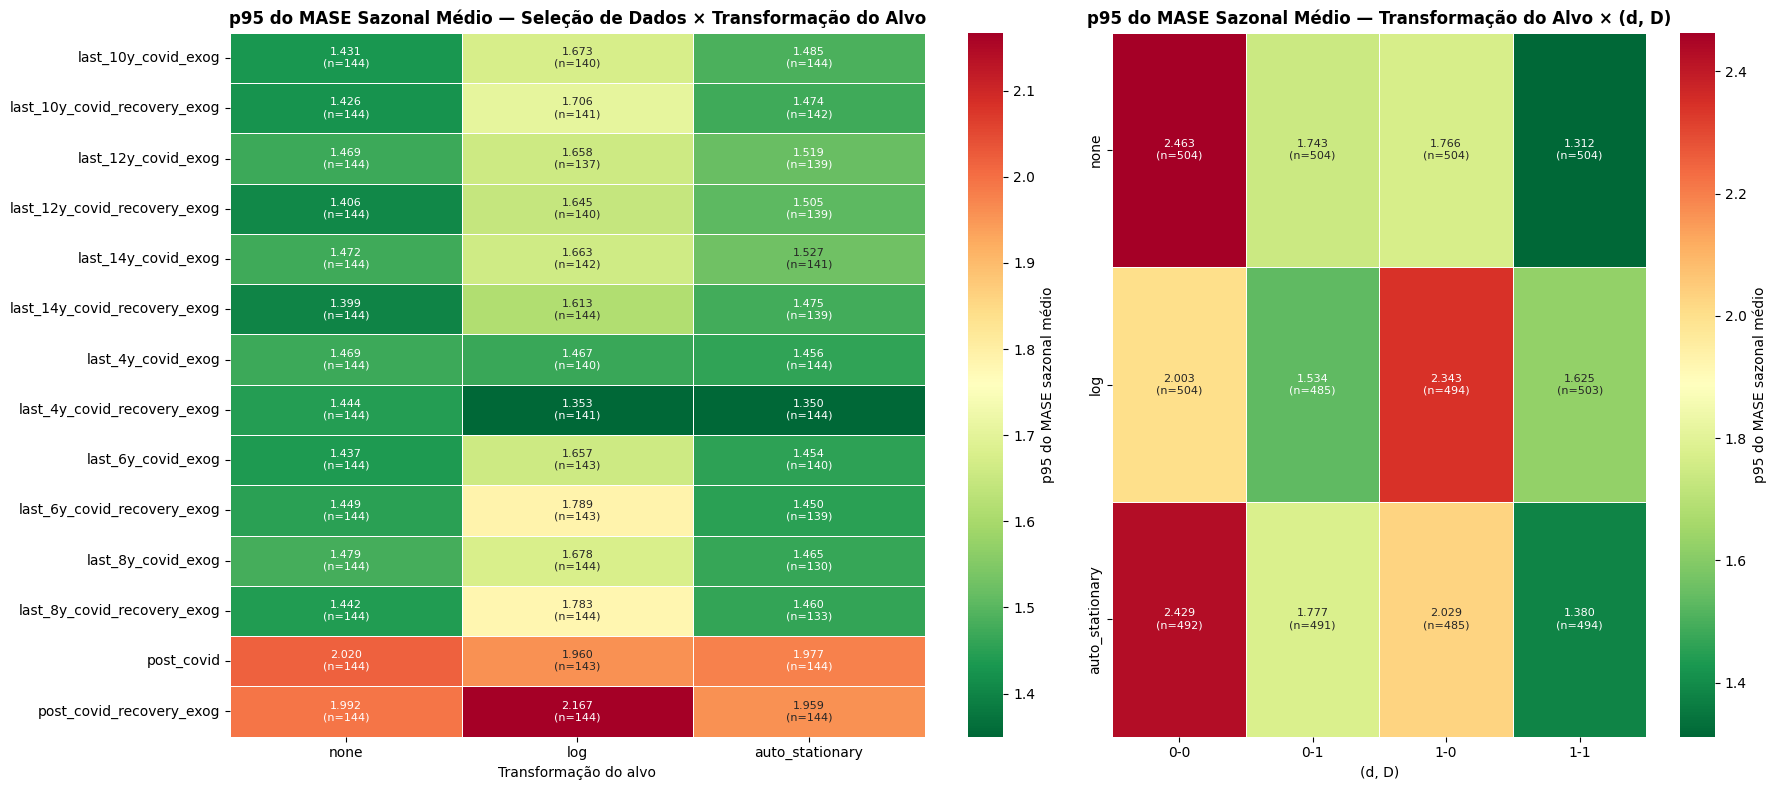

target_transform,none,log,auto_stationary,best
data_selection,,,,
last_10y_covid_exog,1.431,1.673,1.485,none
last_10y_covid_recovery_exog,1.426,1.706,1.474,none
last_12y_covid_exog,1.469,1.658,1.519,none
last_12y_covid_recovery_exog,1.406,1.645,1.505,none
last_14y_covid_exog,1.472,1.663,1.527,none
last_14y_covid_recovery_exog,1.399,1.613,1.475,none
last_4y_covid_exog,1.469,1.467,1.456,auto_stationary
last_4y_covid_recovery_exog,1.444,1.353,1.350,auto_stationary
last_6y_covid_exog,1.437,1.657,1.454,none


d                     0             1       
D                     0      1      0      1
target_transform                            
none              2.463  1.743  1.766  1.312
log               2.003  1.534  2.343  1.625
auto_stationary   2.429  1.777  2.029  1.380

In [10]:
P95_QUANTILE = 0.05  # p95: the value only the best 5% of a cell's models beat


def p95(values):
    return values.quantile(P95_QUANTILE)


def p95_pivot(index, columns):
    """p95 of the mean seasonal MASE per cell, and the number of models per cell."""
    kwargs = {'index': index, 'columns': columns, 'values': 'mase_mean'}
    return (
        results_df.pivot_table(**kwargs, aggfunc=p95),
        results_df.pivot_table(**kwargs, aggfunc='count'),
    )


def p95_labels(pivot, counts):
    """Cell labels: the p95 value and, below it, the number of models."""
    return pd.DataFrame(
        [
            ['' if pd.isna(v) else f'{v:.3f}\n(n={int(n)})' for v, n in zip(values, ns)]
            for values, ns in zip(pivot.to_numpy(), counts.to_numpy())
        ],
        index=pivot.index,
        columns=pivot.columns,
    )


p95_by_selection_transform, n_by_selection_transform = (
    frame.reindex(columns=TARGET_TRANSFORMS)
    for frame in p95_pivot('data_selection', 'target_transform')
)
p95_by_transform_diff, n_by_transform_diff = (
    frame.reindex(TARGET_TRANSFORMS)
    for frame in p95_pivot('target_transform', ['d', 'D'])
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.3, 1]})
for ax, pivot, counts, title, xlabel in [
    (
        axes[0],
        p95_by_selection_transform,
        n_by_selection_transform,
        'Seleção de Dados × Transformação do Alvo',
        'Transformação do alvo',
    ),
    (
        axes[1],
        p95_by_transform_diff,
        n_by_transform_diff,
        'Transformação do Alvo × (d, D)',
        '(d, D)',
    ),
]:
    sns.heatmap(
        pivot,
        annot=p95_labels(pivot, counts),
        fmt='',
        annot_kws={'fontsize': 8},
        cmap='RdYlGn_r',
        linewidths=0.4,
        ax=ax,
        cbar_kws={'label': 'p95 do MASE sazonal médio'},
    )
    ax.set_title(f'p95 do MASE Sazonal Médio — {title}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

display(
    p95_by_selection_transform.assign(
        best=p95_by_selection_transform.idxmin(axis=1)
    ).round(3)
)
display(p95_by_transform_diff.round(3))

## Diagnósticos do Melhor Modelo


In [11]:
top10 = results_df.head(10).copy()

display(
    top10[
        [
            'data_selection',
            'run_name',
            *AGG_METRICS,
            'aicc',
            'aic',
            'bic',
            *METRICS,
        ]
    ]
)

,data_selection,run_name,mase_mean,mase_worst,mase_post,n_origins,aicc,aic,bic,rmse,mae,mape,r2,mase,forecast_bias
0,last_4y_covid_recovery_exog,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992006,1.257627,1.137286,4,-4.818133,-10.818133,-4.550999,103693.084207,65358.584198,7.301984,0.902169,1.257627,7.930565
1,last_4y_covid_recovery_exog,"SARIMAX(2,1,2)(0,1,1)[12] (last_4y_covid_recov...",1.071647,1.449711,1.275819,4,-5.963985,-17.963985,-9.607805,113038.835958,75341.124798,8.489936,0.883739,1.449711,7.431318
2,last_4y_covid_recovery_exog,"SARIMAX(1,1,1)(0,1,1)[12] (last_4y_covid_recov...",1.136900,1.465201,1.451922,4,-6.551819,-12.151819,-5.605564,113123.406798,74765.901076,8.541981,0.883565,1.438642,9.258209
3,last_4y_covid_recovery_exog,"SARIMAX(1,1,2)(0,1,1)[12] (last_4y_covid_recov...",1.167229,1.558576,1.479311,4,-11.858253,-20.473637,-13.161980,110813.694624,72760.082876,8.108549,0.888271,1.400046,6.417805
4,last_4y_covid_recovery_exog,"SARIMAX(0,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.175090,2.182530,1.529951,4,577.583804,571.983804,578.530059,153634.495344,113425.572634,14.137834,0.785239,2.182530,5.330330
5,last_4y_covid_exog,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_exog ...",1.189968,1.594258,1.533209,4,-7.358929,-11.358929,-6.136317,121969.345691,82853.229982,9.530421,0.864643,1.594258,10.597316
6,last_4y_covid_recovery_exog,"SARIMAX(1,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.199021,2.190350,1.535128,4,581.969695,573.969695,581.606993,154985.786250,113831.978932,14.133870,0.781444,2.190350,5.629387
7,last_4y_covid_recovery_exog,"SARIMAX(0,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.219302,2.377222,1.627297,4,585.813771,580.213771,586.760026,201791.934756,123543.671207,13.710863,0.629502,2.377222,10.540642
8,last_4y_covid_recovery_exog,"SARIMAX(0,1,2)(1,1,1)[12] (last_4y_covid_recov...",1.228707,2.219643,1.564486,4,556.897223,548.281839,555.593496,156537.101477,115354.338279,14.368897,0.777047,2.219643,5.283367
9,last_4y_covid_recovery_exog,"SARIMAX(1,1,1)(1,1,1)[12] (last_4y_covid_recov...",1.236524,2.344273,1.612089,4,590.181055,582.181055,589.818353,200435.717306,121831.305406,13.420519,0.634465,2.344273,10.631634


In [12]:
def fit_model(row, configs):
    """Refit a configuration at the latest origin (trained up to the end of train)."""
    cfg = configs[(LATEST_ORIGIN, row['data_selection'], row['target_transform'])]
    return SARIMAX(
        cfg['series'],
        exog=cfg['exog_train'],
        order=row['order'],
        seasonal_order=row['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


top10_fits = [fit_model(row, model_configs) for _, row in top10.iterrows()]

for i, (_, row) in enumerate(top10.iterrows()):
    print(f'#{i + 1:>2}  [{row["data_selection"]}]  {row["run_name"]}')

# 1  [last_4y_covid_recovery_exog]  SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recovery_exog | log)
# 2  [last_4y_covid_recovery_exog]  SARIMAX(2,1,2)(0,1,1)[12] (last_4y_covid_recovery_exog | log)
# 3  [last_4y_covid_recovery_exog]  SARIMAX(1,1,1)(0,1,1)[12] (last_4y_covid_recovery_exog | log)
# 4  [last_4y_covid_recovery_exog]  SARIMAX(1,1,2)(0,1,1)[12] (last_4y_covid_recovery_exog | log)
# 5  [last_4y_covid_recovery_exog]  SARIMAX(0,1,1)(1,1,1)[12] (last_4y_covid_recovery_exog | auto_stationary)
# 6  [last_4y_covid_exog]  SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_exog | log)
# 7  [last_4y_covid_recovery_exog]  SARIMAX(1,1,1)(1,1,1)[12] (last_4y_covid_recovery_exog | auto_stationary)
# 8  [last_4y_covid_recovery_exog]  SARIMAX(0,1,1)(1,1,1)[12] (last_4y_covid_recovery_exog | none)
# 9  [last_4y_covid_recovery_exog]  SARIMAX(0,1,2)(1,1,1)[12] (last_4y_covid_recovery_exog | auto_stationary)
#10  [last_4y_covid_recovery_exog]  SARIMAX(1,1,1)(1,1,1)[12] (last_4y_covid_recovery_exog | none)


### Diagnóstico de Resíduos


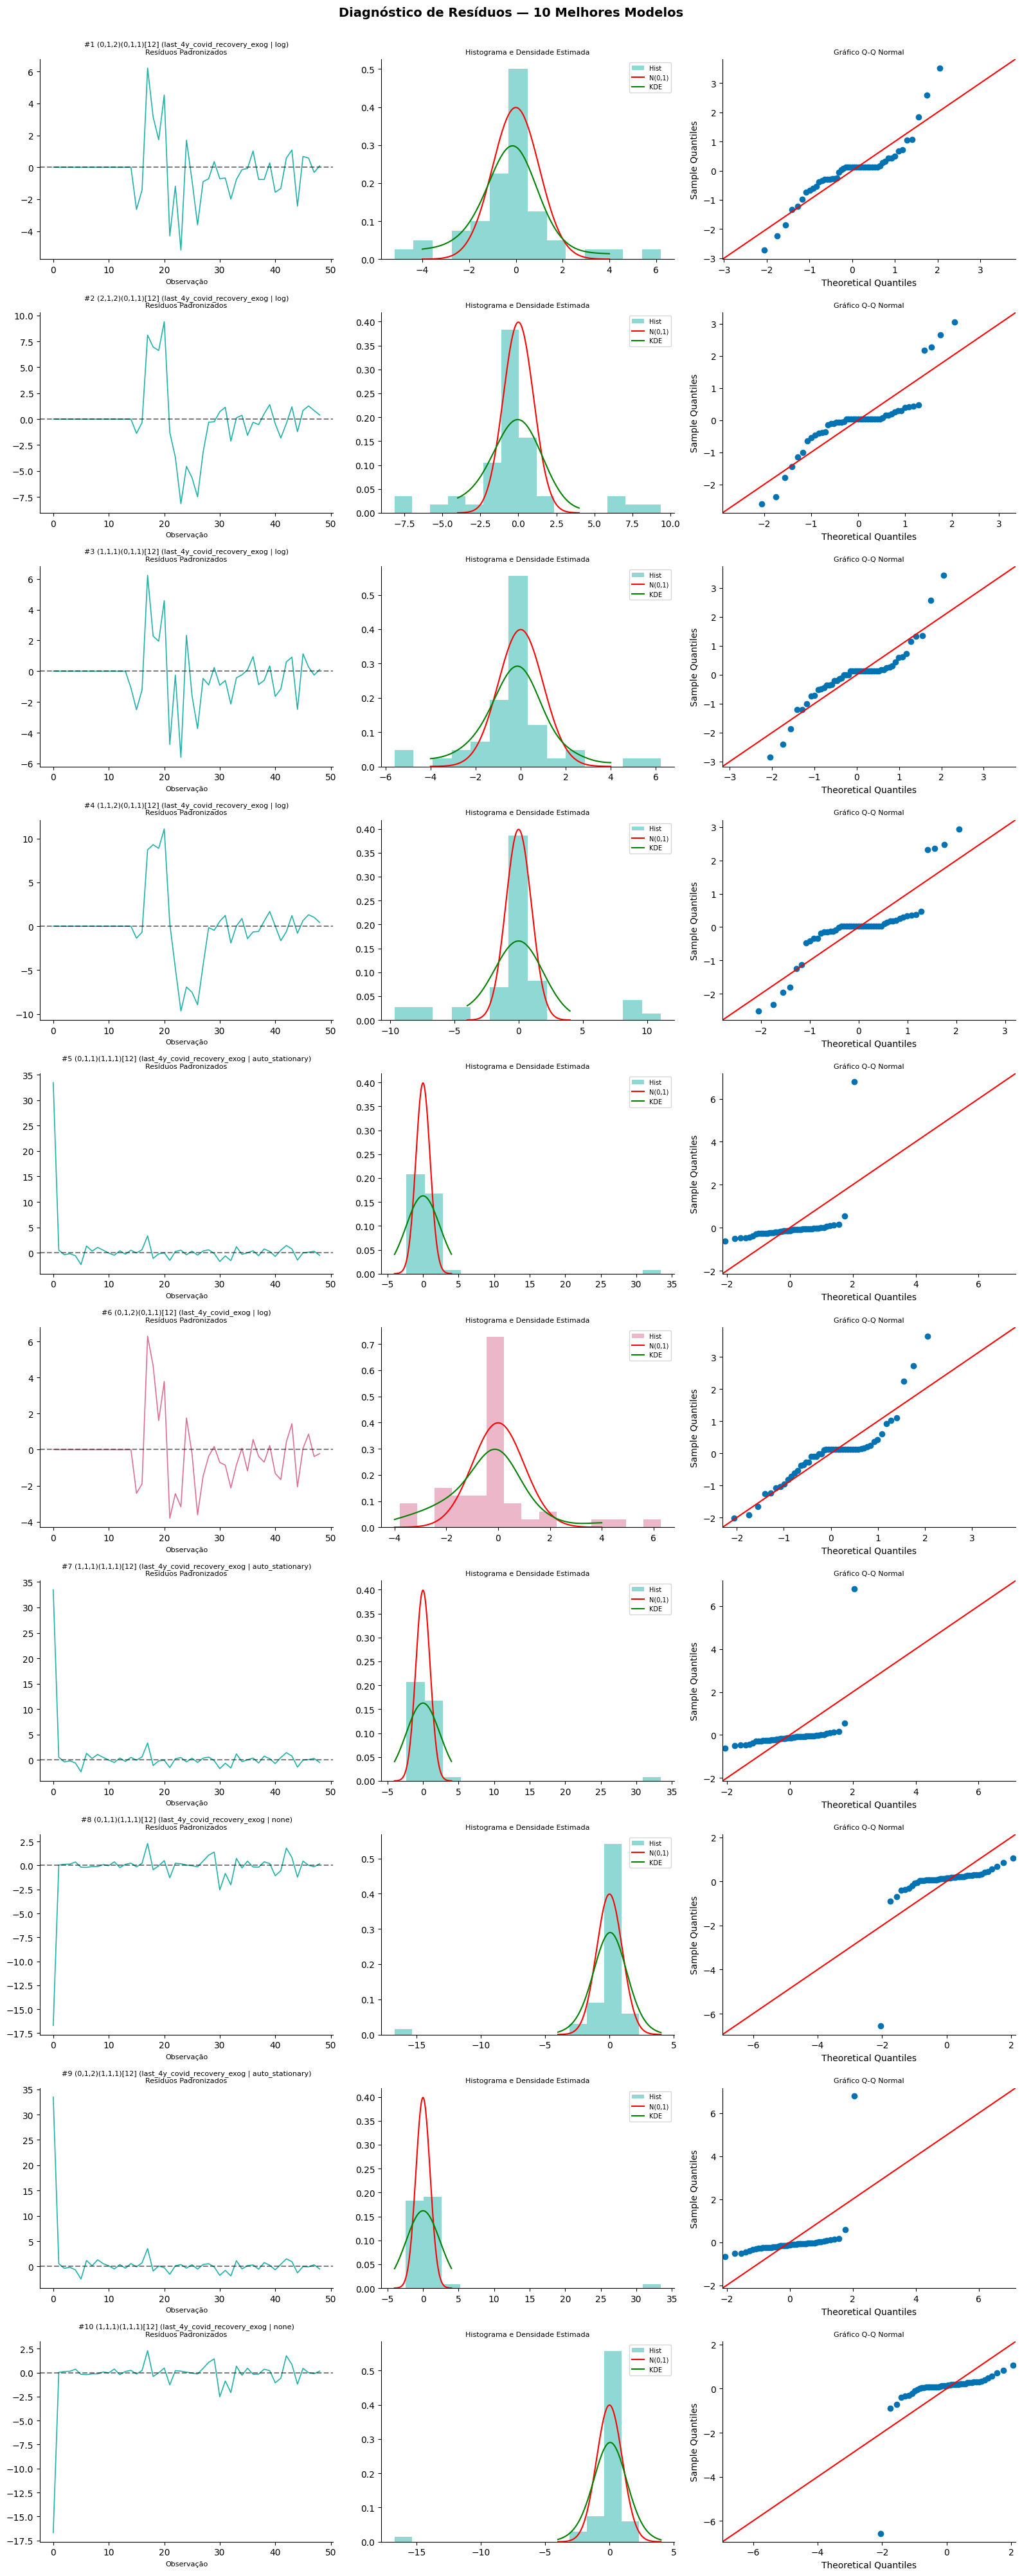

In [13]:
fig, axes = plt.subplots(10, 3, figsize=(16, 40))
fig.suptitle(
    'Diagnóstico de Resíduos — 10 Melhores Modelos', fontsize=14, fontweight='bold', y=1.001
)

x_qq = np.linspace(-4, 4, 200)

for i, ((_, row), fit) in enumerate(zip(top10.iterrows(), top10_fits)):
    std_resid = fit.filter_results.standardized_forecasts_error[0]
    std_resid = std_resid[~np.isnan(std_resid)]

    row_label = f'#{i + 1} {row["run_name"].replace("SARIMAX", "")}'

    # Standardized residuals over time
    axes[i, 0].plot(std_resid, linewidth=1.2, color=palette[row['data_selection']])
    axes[i, 0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[i, 0].set_title(f'{row_label}\nResíduos Padronizados', fontsize=8)
    axes[i, 0].set_xlabel('Observação', fontsize=8)
    sns.despine(ax=axes[i, 0])

    # Histogram + KDE + N(0,1)
    axes[i, 1].hist(
        std_resid,
        bins='auto',
        density=True,
        alpha=0.5,
        color=palette[row['data_selection']],
        label='Hist',
    )
    axes[i, 1].plot(x_qq, stats.norm.pdf(x_qq, 0, 1), 'r-', label='N(0,1)')
    kde = stats.gaussian_kde(std_resid)
    axes[i, 1].plot(x_qq, kde(x_qq), 'g-', label='KDE')
    axes[i, 1].set_title('Histograma e Densidade Estimada', fontsize=8)
    axes[i, 1].legend(fontsize=7)
    sns.despine(ax=axes[i, 1])

    # Normal Q-Q plot
    sm.qqplot(std_resid, line='45', fit=True, ax=axes[i, 2])
    axes[i, 2].set_title('Gráfico Q-Q Normal', fontsize=8)
    sns.despine(ax=axes[i, 2])

plt.tight_layout()
plt.show()

### Resultado Final


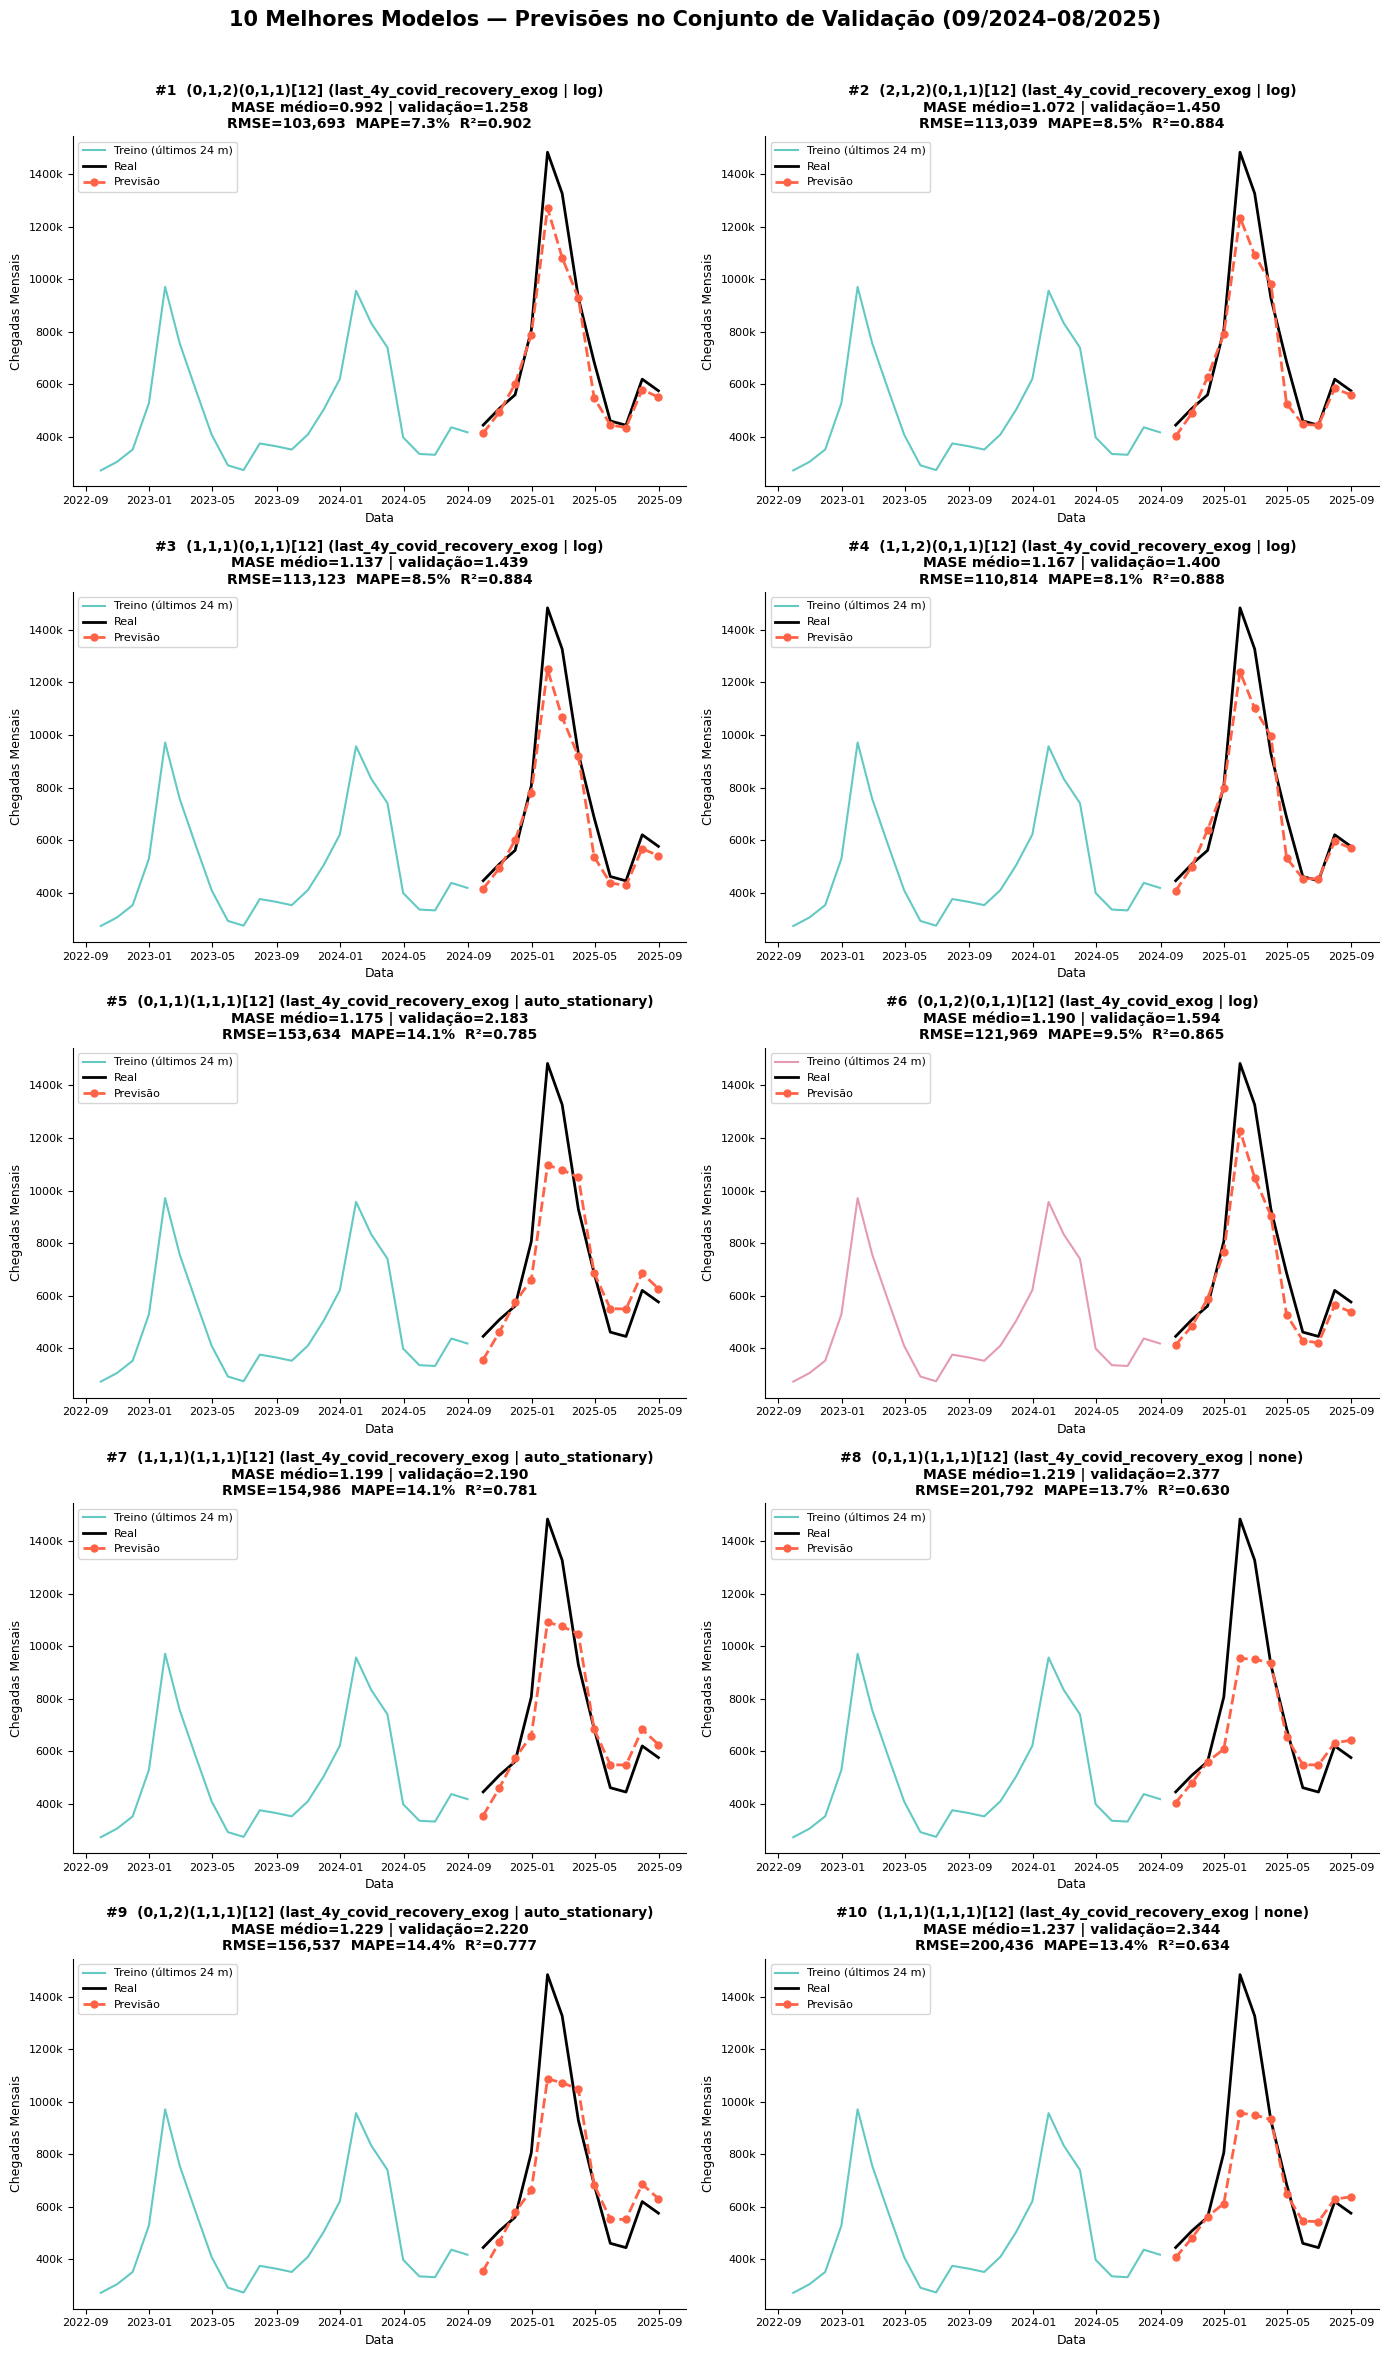

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(14, 24))
fig.suptitle(
    f'10 Melhores Modelos — Previsões no Conjunto de Validação '
    f'({val_monthly.index[0]:%m/%Y}–{val_monthly.index[-1]:%m/%Y})',
    fontsize=15,
    fontweight='bold',
)

for i, (ax, (_, row), fit) in enumerate(zip(axes.flat, top10.iterrows(), top10_fits)):
    cfg = model_configs[(LATEST_ORIGIN, row['data_selection'], row['target_transform'])]
    forecast = forecast_arrivals(fit, cfg)
    train_plot = cfg['raw_series'].iloc[-24:]

    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Treino (últimos 24 m)',
        linewidth=1.5,
        color=palette[row['data_selection']],
        alpha=0.7,
    )
    ax.plot(
        val_monthly.index,
        val_monthly['arrival_count'],
        label='Real',
        linewidth=2,
        color='black',
    )
    ax.plot(
        val_monthly.index,
        forecast,
        label='Previsão',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )

    ax.set_title(
        f'#{i + 1}  {row["run_name"].replace("SARIMAX", "")}\n'
        f'MASE médio={row["mase_mean"]:.3f} | validação={row["mase"]:.3f}\n'
        f'RMSE={row["rmse"]:,.0f}  MAPE={row["mape"]:.1f}%  R²={row["r2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Data', fontsize=9)
    ax.set_ylabel('Chegadas Mensais', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Salvar as Previsões de Validação da Melhor Configuração

O notebook de ensembling (10) combina a melhor configuração de cada abordagem, necessitando de suas **previsões**.
A melhor configuração deste notebook é reexecutada em cada origem de validação e suas previsões são registradas como o artefato `validation_forecasts.csv` com a tag `role = best_validation_forecasts` no MLflow.


In [15]:
best_row = results_df.iloc[0]
best_forecasts = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for origin in ORIGINS:
        selection = selections_by_origin[origin].get(best_row['data_selection'])
        if selection is None:
            continue  # the data selection does not exist at this origin
        data_key = selection.get('alias_of', best_row['data_selection'])
        cfg = model_configs[(origin, data_key, best_row['target_transform'])]
        fit = SARIMAX(
            cfg['series'],
            exog=cfg['exog_train'],
            order=best_row['order'],
            seasonal_order=best_row['seasonal_order'],
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        forecast = forecast_arrivals(fit, cfg)
        best_forecasts.append(
            pd.DataFrame({
                'origin': origin_label(origin),
                'date': cfg['val_actual'].index,
                'actual': cfg['val_actual'].to_numpy(),
                'forecast': forecast,
                'mase': score(cfg['val_actual'], forecast, origin)['mase'],
            })
        )
best_forecasts = pd.concat(best_forecasts, ignore_index=True)
mase_mean = float(best_forecasts.groupby('origin')['mase'].first().mean())
assert np.isclose(mase_mean, best_row['mase_mean']), (mase_mean, best_row['mase_mean'])


def log_validation_forecasts(approach, configuration, forecasts, mase_mean):
    """Log the best configuration's forecasts at every origin as an MLflow artifact."""
    with mlflow.start_run(
        run_name=f'BEST validation forecasts | {configuration}'[:250]
    ):
        mlflow.set_tags({'role': 'best_validation_forecasts', 'approach': approach})
        mlflow.log_params({
            'configuration': configuration[:500],
            'origins': ', '.join(sorted(forecasts['origin'].unique())),
            'horizon': HORIZON,
        })
        mlflow.log_metric('MASE_mean', mase_mean)
        mlflow.log_text(forecasts.to_csv(index=False), 'validation_forecasts.csv')
    print(f'{approach}: logged {len(forecasts)} forecasts of {configuration}')


log_validation_forecasts(
    'SARIMAX', best_row['run_name'], best_forecasts.drop(columns='mase'), mase_mean
)
best_forecasts.groupby('origin')['mase'].first().round(3)

SARIMAX: logged 48 forecasts of SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recovery_exog | log)


origin
2017-08    0.723
2018-08    0.970
2023-08    1.017
2024-08    1.258
Name: mase, dtype: float64